In [1]:
# ==========================================
# CARGA DE MODELOS ENTRENADOS Y PREPROCESAMIENTO
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import joblib
import urllib.request
import zipfile
import geopandas as gpd
from shapely.geometry import Point
from pathlib import Path
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from cuml.ensemble import RandomForestRegressor as CUMLRandomForestRegressor

CSV_BASE   = Path("/kaggle/input/datasets/yapoksfrod/data-prep-clean/data_prep_clean.csv")
TARGET_COL = "Apparent Geothermal Gradient (°C/Km)"
OUT_DIR    = Path("/kaggle/working/run_comparison")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Ruta al dataset con los modelos
MODEL_DIR  = Path("/kaggle/input/datasets/yapoksfrod/results-tabular-models/results_tabular_models/run_comparison")

# ── Carga y limpieza del CSV ──────────────────────────────────────────────────
df_base = pd.read_csv(CSV_BASE, delimiter=";")
if df_base.columns[-1].startswith('Unnamed'):
    df_base = df_base.iloc[:, :-1]

exclude_cols = ['ID', 'Latitude', 'Longitude', TARGET_COL, 'Surface Temperature (°C)', 'Volcanic weight']
tabular_cols = [c for c in df_base.columns if c not in exclude_cols]
for col in tabular_cols:
    if df_base[col].dtype == 'bool':
        df_base[col] = df_base[col].astype(int)

# ── Preprocesamiento idéntico al entrenamiento ────────────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=42)

train_df, test_df = train_test_split(df_base, test_size=0.2, random_state=42)

imputer = KNNImputer(n_neighbors=8)
train_df = train_df.copy(); test_df = test_df.copy()
train_df[tabular_cols] = imputer.fit_transform(train_df[tabular_cols])
test_df[tabular_cols]  = imputer.transform(test_df[tabular_cols])

scaler = StandardScaler()
train_df[tabular_cols] = scaler.fit_transform(train_df[tabular_cols])
test_df[tabular_cols]  = scaler.transform(test_df[tabular_cols])

min_target   = train_df[TARGET_COL].min()
target_shift = abs(min_target) + 1.0 if min_target <= 0 else 0.0

y_train_log   = np.log1p(train_df[TARGET_COL] + target_shift)
y_test_log    = np.log1p(test_df[TARGET_COL]  + target_shift)

target_scaler = joblib.load(MODEL_DIR / "target_scaler.pkl")
y_train_scaled = target_scaler.transform(y_train_log.values.reshape(-1, 1)).flatten()
y_test_scaled  = target_scaler.transform(y_test_log.values.reshape(-1, 1)).flatten()

X_train = train_df[tabular_cols]
X_test  = test_df[tabular_cols]

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")


Train: (3634, 17)  |  Test: (909, 17)


In [2]:
!pip install contextily

In [3]:
def inverse_target_transform(scaled_values, scaler, shift):
    log_values = scaler.inverse_transform(
        np.array(scaled_values).reshape(-1, 1)
    ).flatten()
    return np.expm1(log_values) - shift

# ── Cargar modelos ────────────────────────────────────────────────────────────
best_catb_model    = joblib.load(MODEL_DIR / "catboost_model.pkl")
best_xgb_model     = joblib.load(MODEL_DIR / "xgboost_model.pkl")
best_lgb_model     = joblib.load(MODEL_DIR / "lightgbm_model.pkl")
best_cuml_rf_model = joblib.load(MODEL_DIR / "cuml_rf_model.pkl")

print("Modelos cargados correctamente.")


Modelos cargados correctamente.


In [4]:
# ── Predicciones (escala normalizada) ────────────────────────────────────────
y_train_pred         = best_catb_model.predict(X_train)
y_test_pred          = best_catb_model.predict(X_test)
y_xgb_train_pred     = best_xgb_model.predict(X_train)
y_xgb_test_pred      = best_xgb_model.predict(X_test)
y_lgb_train_pred     = best_lgb_model.predict(X_train)
y_lgb_test_pred      = best_lgb_model.predict(X_test)
y_cuml_rf_train_pred = best_cuml_rf_model.predict(X_train)
y_cuml_rf_test_pred  = best_cuml_rf_model.predict(X_test)

# ── Desnormalizar ─────────────────────────────────────────────────────────────
y_train_orig = inverse_target_transform(y_train_scaled, target_scaler, target_shift)
y_test_orig  = inverse_target_transform(y_test_scaled,  target_scaler, target_shift)

y_catb_train_orig    = inverse_target_transform(y_train_pred,         target_scaler, target_shift)
y_catb_test_orig     = inverse_target_transform(y_test_pred,          target_scaler, target_shift)
y_xgb_train_orig     = inverse_target_transform(y_xgb_train_pred,     target_scaler, target_shift)
y_xgb_test_orig      = inverse_target_transform(y_xgb_test_pred,      target_scaler, target_shift)
y_lgb_train_orig     = inverse_target_transform(y_lgb_train_pred,     target_scaler, target_shift)
y_lgb_test_orig      = inverse_target_transform(y_lgb_test_pred,      target_scaler, target_shift)
y_cuml_rf_train_orig = inverse_target_transform(y_cuml_rf_train_pred, target_scaler, target_shift)
y_cuml_rf_test_orig  = inverse_target_transform(y_cuml_rf_test_pred,  target_scaler, target_shift)

# ── Tabla resumen de métricas ─────────────────────────────────────────────────
def metricas(y_true, y_pred):
    return (mean_absolute_error(y_true, y_pred),
            np.sqrt(mean_squared_error(y_true, y_pred)),
            r2_score(y_true, y_pred))

rows = []
for nombre, y_tr, y_te in [
    ("CatBoost",          y_catb_train_orig,    y_catb_test_orig),
    ("XGBoost",           y_xgb_train_orig,     y_xgb_test_orig),
    ("LightGBM",          y_lgb_train_orig,     y_lgb_test_orig),
    ("cuML RandomForest", y_cuml_rf_train_orig, y_cuml_rf_test_orig),
]:
    mae_tr, rmse_tr, r2_tr = metricas(y_train_orig, y_tr)
    mae_te, rmse_te, r2_te = metricas(y_test_orig,  y_te)
    rows.append({"Modelo": nombre,
                 "MAE Train": mae_tr, "RMSE Train": rmse_tr, "R² Train": r2_tr,
                 "MAE Test":  mae_te, "RMSE Test":  rmse_te, "R² Test":  r2_te})

df_metricas = pd.DataFrame(rows).set_index("Modelo")
display(df_metricas.style
    .format("{:.4f}")
    .highlight_min(subset=["MAE Train","RMSE Train","MAE Test","RMSE Test"], color="lightgreen")
    .highlight_max(subset=["R² Train","R² Test"], color="lightgreen")
    .set_caption("Métricas desnormalizadas (°C/Km)")
)


[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5


,MAE Train,RMSE Train,R² Train,MAE Test,RMSE Test,R² Test
Modelo,,,,,,
CatBoost,2.3797,3.8335,0.5894,2.8165,4.8473,0.3979
XGBoost,2.2483,3.6153,0.6348,2.8065,4.8742,0.3911
LightGBM,2.2858,3.7029,0.6169,2.8274,4.8901,0.3872
cuML RandomForest,2.3368,3.8074,0.5950,2.8133,4.8765,0.3906


In [5]:
# ── Descargar shapefile de Colombia ──────────────────────────────────────────
shp_dir  = OUT_DIR / 'colombia_shp'
shp_dir.mkdir(parents=True, exist_ok=True)
zip_path = shp_dir / 'colombia.zip'
shp_path = shp_dir / 'ne_110m_admin_0_countries.shp'
url      = 'https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip'

if not zip_path.exists():
    urllib.request.urlretrieve(url, zip_path)
if not shp_path.exists():
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(shp_dir)

world = gpd.read_file(shp_path).to_crs(4326)
for col in ['ADM0_A3', 'ISO_A3', 'iso_a3']:
    if col in world.columns:
        colombia = world[world[col] == 'COL']
        break

# ── df_map: lat/lon + real + predicho + ERROR de predicción ──────────────────
df_map = test_df[['Latitude', 'Longitude']].copy().reset_index(drop=True)
df_map['gg_real']    = y_test_orig
df_map['gg_catb']    = y_catb_test_orig
df_map['gg_xgb']     = y_xgb_test_orig
df_map['gg_lgb']     = y_lgb_test_orig
df_map['gg_cuml_rf'] = y_cuml_rf_test_orig

# Error = predicho - real  (positivo -> sobreestimacion, negativo -> subestimacion)
df_map['err_catb']    = df_map['gg_catb']    - df_map['gg_real']
df_map['err_xgb']     = df_map['gg_xgb']     - df_map['gg_real']
df_map['err_lgb']     = df_map['gg_lgb']     - df_map['gg_real']
df_map['err_cuml_rf'] = df_map['gg_cuml_rf'] - df_map['gg_real']

# ── Escala simetrica para el mapa de error ───────────────────────────────────
all_errors = pd.concat([
    df_map['err_catb'], df_map['err_xgb'],
    df_map['err_lgb'],  df_map['err_cuml_rf']
])
max_abs = np.ceil(all_errors.abs().max())
print(f"Rango simétrico del error: ±{max_abs:.1f} °C/Km")

# Colormap para error: azul -> blanco (0) -> rojo
cmap_err = plt.cm.RdBu_r
norm_err = mcolors.TwoSlopeNorm(vmin=-max_abs, vcenter=0.0, vmax=max_abs)

# Colormap para GG real/predicho
all_gg  = pd.concat([df_map['gg_real'], df_map['gg_catb'],
                     df_map['gg_xgb'],  df_map['gg_lgb'], df_map['gg_cuml_rf']])
cmap_gg = cm.RdYlBu_r
norm_gg = mcolors.Normalize(vmin=all_gg.min(), vmax=all_gg.max())

print("Setup geoespacial listo.")


Rango simétrico del error: ±43.0 °C/Km
Setup geoespacial listo.


In [6]:
try:
    import contextily as ctx
    HAS_CTX = True
except ImportError:
    HAS_CTX = False

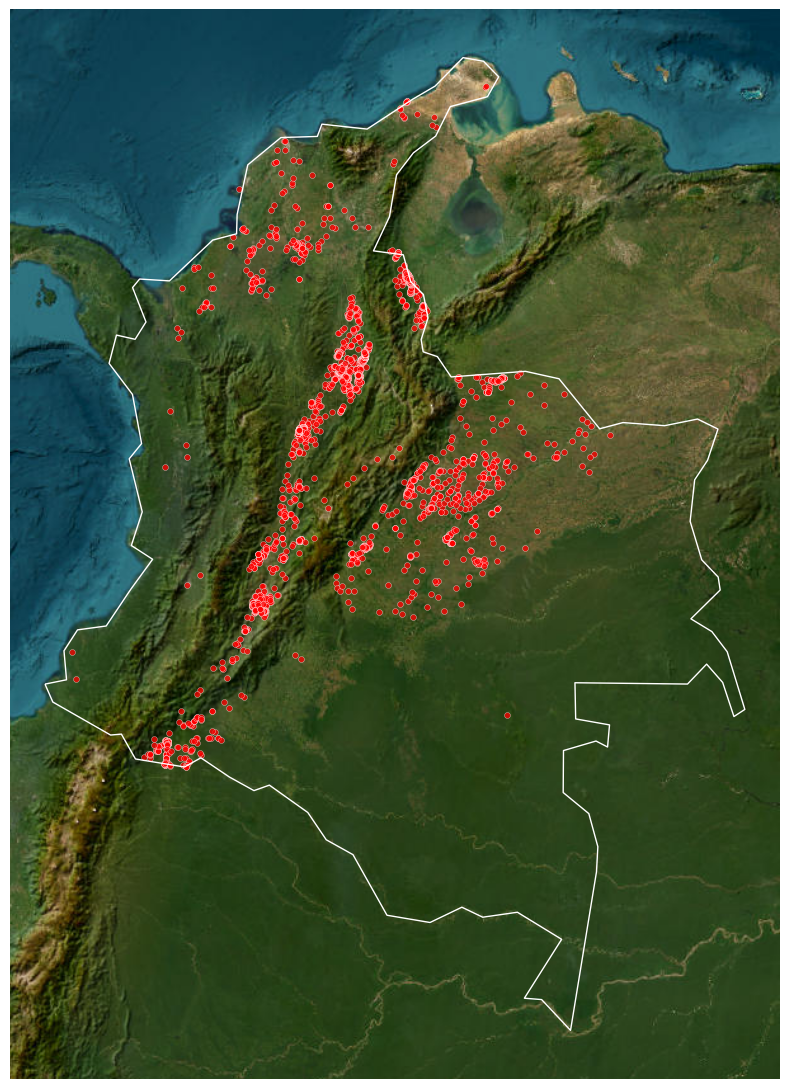

Guardado: mapa_ubicacion_pozos.png / .pdf


In [7]:
# ── GeoDataFrame con TODOS los pozos de la base de datos ─────────────────────
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.ticker as mticker

try:
    from matplotlib_scalebar.scalebar import ScaleBar
    HAS_SCALEBAR = True
except ImportError:
    HAS_SCALEBAR = False
    print("matplotlib-scalebar no disponible")

gdf_todos = gpd.GeoDataFrame(
    df_base[["Latitude", "Longitude"]].copy(),
    geometry=[Point(xy) for xy in zip(df_base["Longitude"], df_base["Latitude"])],
    crs="EPSG:4326",
)


def dibujar_brujula_pro(ax, x=0.07, y=0.82, r=0.032):
    """Rosa de los vientos: solo puntas doradas y letras cardinales, sin fondo."""
    # 16 puntas todas doradas
    for i in range(16):
        ang   = np.radians(i * 22.5 - 90)
        largo = r * 1.25 if i % 2 == 0 else r * 0.65
        pts   = np.array([
            [x + np.cos(ang - np.pi/16) * r * 0.12,
             y + np.sin(ang - np.pi/16) * r * 0.12],
            [x + np.cos(ang)            * largo,
             y + np.sin(ang)            * largo],
            [x + np.cos(ang + np.pi/16) * r * 0.12,
             y + np.sin(ang + np.pi/16) * r * 0.12],
        ])
        ax.add_patch(plt.Polygon(pts, closed=True, color="#e8c840", ec="#a07800",
                                 lw=0.6, transform=ax.transAxes, zorder=10, clip_on=False))
    # Círculo central dorado
    ax.add_patch(plt.Circle((x, y), r * 0.18, color="#e8c840", ec="#a07800",
                             lw=0.8, transform=ax.transAxes, zorder=11, clip_on=False))
    # Letras cardinales
    for letra, dx, dy in [("N", 0, r*1.65), ("S", 0, -r*1.65),
                           ("E", r*1.65, 0), ("O", -r*1.65, 0)]:
        ax.text(x + dx, y + dy, letra, transform=ax.transAxes,
                ha="center", va="center", fontsize=8,
                fontweight="bold" if letra == "N" else "normal",
                color="white", zorder=13, clip_on=False,
                path_effects=[pe.withStroke(linewidth=2.5, foreground="black")])


def dibujar_marco_km(ax, paso_km=200):
    """
    Marco con ticks en km desde la esquina inferior-izquierda,
    en los cuatro bordes. Funciona sobre ejes en EPSG:3857 (metros).
    Los ticks están en metros pero las etiquetas muestran km.
    """
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    total_m_x = xlim[1] - xlim[0]
    total_m_y = ylim[1] - ylim[0]
    paso_m    = paso_km * 1000

    ticks_x = np.arange(xlim[0], xlim[1] + 1, paso_m)
    ticks_y = np.arange(ylim[0], ylim[1] + 1, paso_m)

    # Etiquetas relativas al origen (esquina inf-izq = 0 km)
    labels_x = [f"{int(round((t - xlim[0]) / 1000))} km" for t in ticks_x]
    labels_y = [f"{int(round((t - ylim[0]) / 1000))} km" for t in ticks_y]

    ax.set_xticks(ticks_x); ax.set_xticklabels(labels_x, fontsize=7, rotation=30, ha="right")
    ax.set_yticks(ticks_y); ax.set_yticklabels(labels_y, fontsize=7)

    # Ticks en los cuatro lados
    ax.tick_params(which="both", bottom=True, top=True, left=True, right=True,
                   labelbottom=True, labeltop=True, labelleft=True, labelright=True,
                   length=4, width=0.8, color="#333333")

    ax.grid(True, color="#aaaaaa", linewidth=0.3, linestyle="--", alpha=0.5, zorder=0)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
        spine.set_edgecolor("#222222")


# ── Figura en EPSG:3857 para que los metros sean consistentes ────────────────
gdf_todos_web = gdf_todos.to_crs(epsg=3857)
colombia_web  = colombia.to_crs(epsg=3857)

def generar_mapa_pozos(brujula_x, brujula_y, brujula_r, filename):
    fig, ax = plt.subplots(figsize=(9, 11))
    colombia_web.boundary.plot(ax=ax, color="white", linewidth=1.0)
    gdf_todos_web.plot(ax=ax, color="steelblue", markersize=18,
                       alpha=0.80, edgecolor="white", linewidth=0.3)
    if HAS_CTX:
        try:
            ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery, attribution=False)
        except Exception:
            ctx.add_basemap(ax, source=ctx.providers.OpenTopoMap, attribution=False)
        colombia_web.boundary.plot(ax=ax, color="white", linewidth=1.0)
        gdf_todos_web.plot(ax=ax, color="steelblue", markersize=18,
                           alpha=0.80, edgecolor="white", linewidth=0.3)
    else:
        colombia_web.plot(ax=ax, color="#eaf0e8", edgecolor="#333333", linewidth=0.8)
    dibujar_marco_km(ax, paso_km=200)
    if HAS_SCALEBAR:
        scalebar = ScaleBar(1, units="m", dimension="si-length",
                            length_fraction=0.20, location="lower left",
                            scale_loc="bottom", color="black",
                            box_color="white", box_alpha=0.75,
                            font_properties={"size": 8})
        ax.add_artist(scalebar)
    dibujar_brujula_pro(ax, x=brujula_x, y=brujula_y, r=brujula_r)
    plt.tight_layout()
    fig.savefig(OUT_DIR / f"{filename}.png", dpi=300, bbox_inches="tight")
    fig.savefig(OUT_DIR / f"{filename}.pdf", dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Guardado: {filename}.png / .pdf")

# Versión 1: brújula movida a superior izquierda, tamaño original
generar_mapa_pozos(brujula_x=0.07, brujula_y=0.82, brujula_r=0.048,
                   filename="mapa_ubicacion_pozos_brujula_movida")

# Versión 2: brújula superior izquierda y más pequeña
generar_mapa_pozos(brujula_x=0.07, brujula_y=0.85, brujula_r=0.028,
                   filename="mapa_ubicacion_pozos_brujula_pequeña")


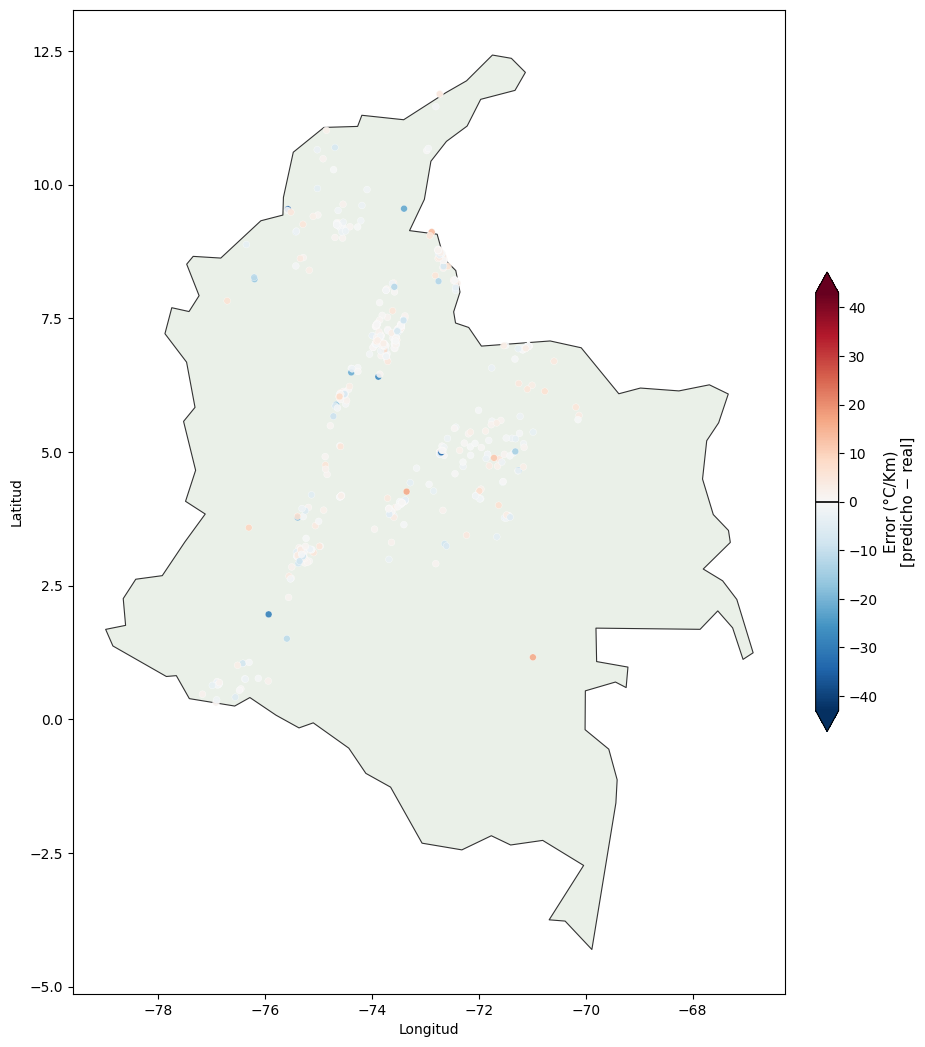

Guardado: mapa_error_catboost_sinctx.png / .pdf


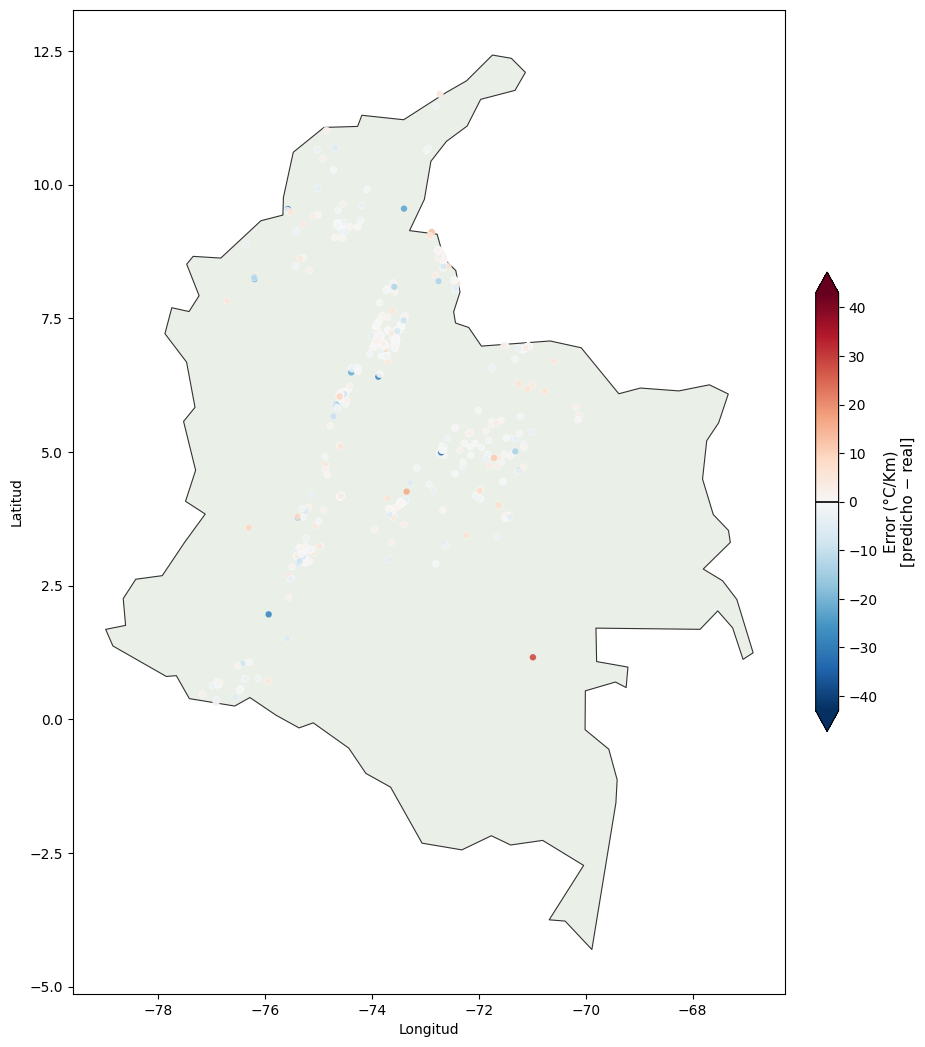

Guardado: mapa_error_xgboost_sinctx.png / .pdf


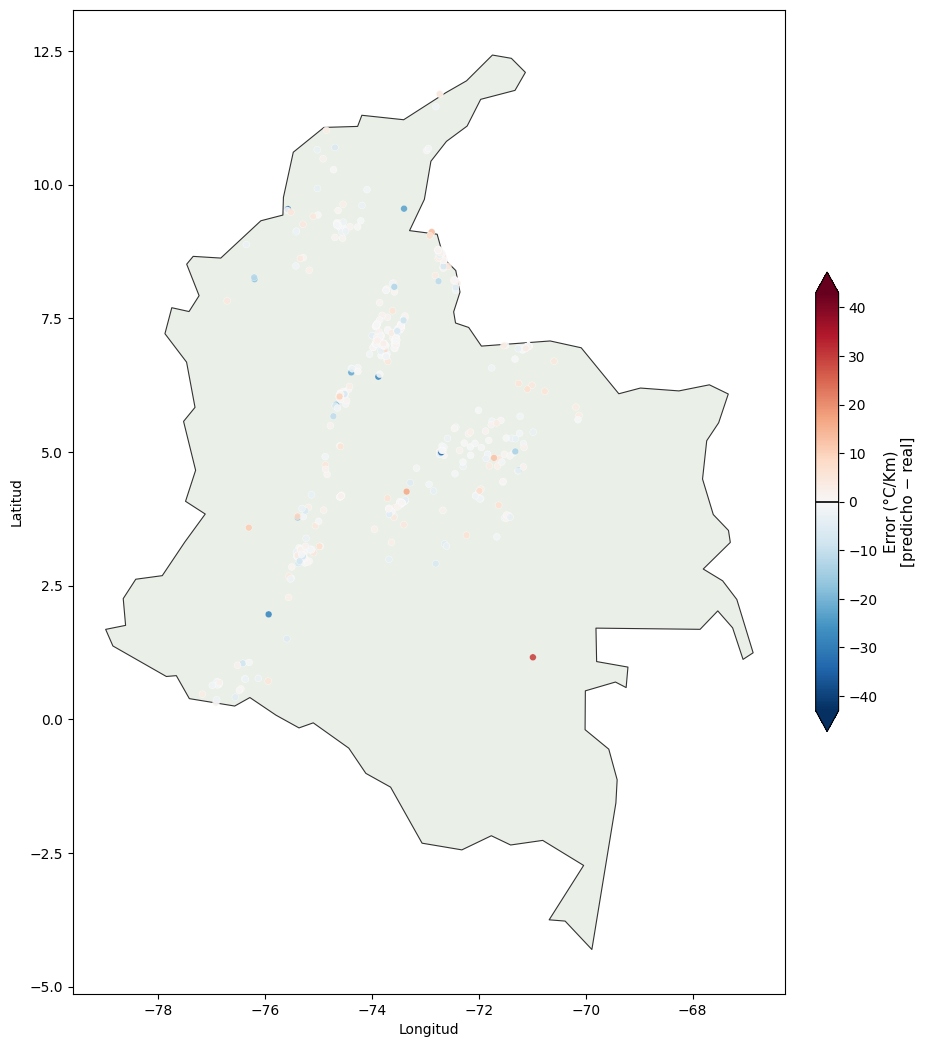

Guardado: mapa_error_lightgbm_sinctx.png / .pdf


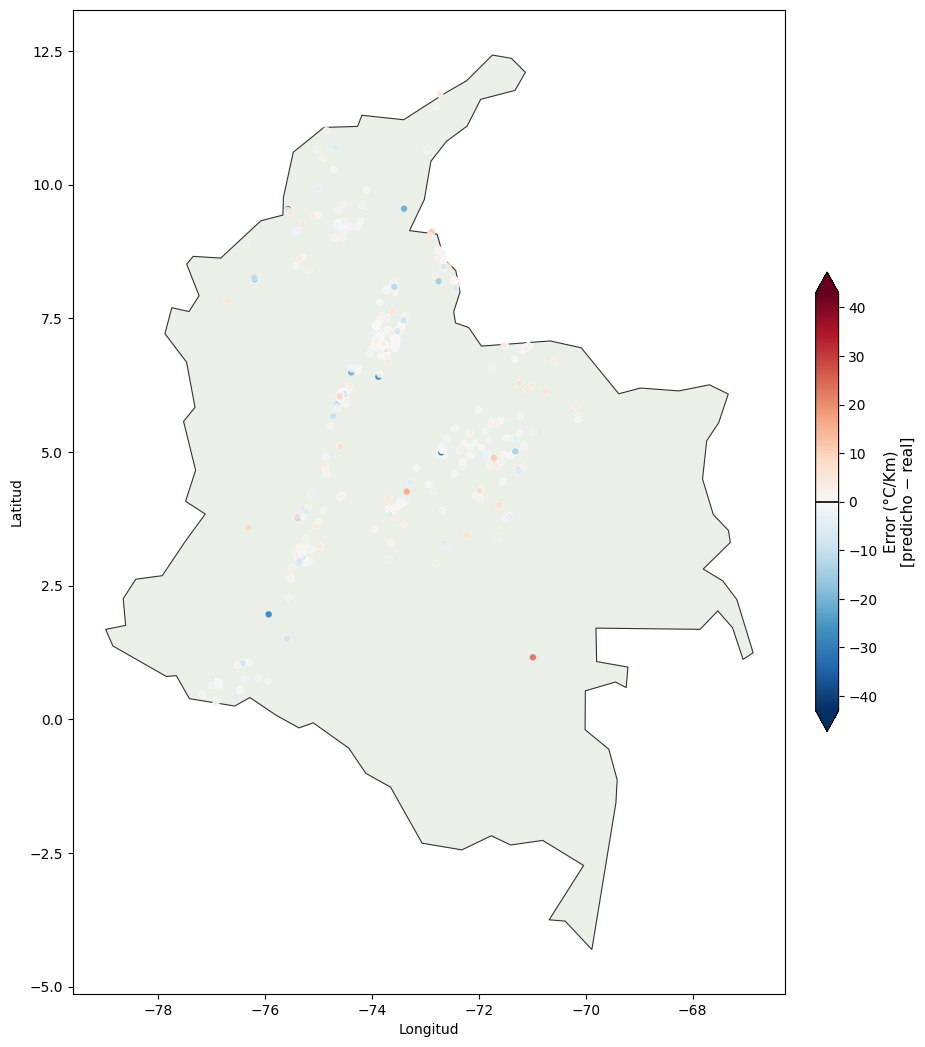

Guardado: mapa_error_cumlrf_sinctx.png / .pdf


In [8]:
def plot_mapa_error_sin_ctx(col_error, titulo, filename):
    gdf = gpd.GeoDataFrame(
        df_map[[col_error]].copy(),
        geometry=[Point(xy) for xy in zip(df_map['Longitude'], df_map['Latitude'])],
        crs='EPSG:4326'
    )
    fig, ax = plt.subplots(figsize=(9, 11))
    colombia.plot(ax=ax, color='#eaf0e8', edgecolor='#333333', linewidth=0.8)
    gdf.plot(
        column=col_error, cmap=cmap_err, norm=norm_err,
        markersize=24, alpha=0.90, edgecolor='white',
        linewidth=0.25, legend=False, ax=ax,
    )
    sm   = cm.ScalarMappable(cmap=cmap_err, norm=norm_err)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.04, extend='both')
    cbar.set_label('Error (°C/Km)\n[predicho − real]', fontsize=11)
    cbar.ax.axhline(y=0, color='black', linewidth=1.2)
    ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
    ax.set_aspect('equal')
    plt.tight_layout()
    fig.savefig(OUT_DIR / f'{filename}.png', dpi=300, bbox_inches='tight')
    fig.savefig(OUT_DIR / f'{filename}.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Guardado: {filename}.png / .pdf")

plot_mapa_error_sin_ctx('err_catb',    'Error de Predicción — CatBoost (°C/Km)',          'mapa_error_catboost_sinctx')
plot_mapa_error_sin_ctx('err_xgb',     'Error de Predicción — XGBoost (°C/Km)',           'mapa_error_xgboost_sinctx')
plot_mapa_error_sin_ctx('err_lgb',     'Error de Predicción — LightGBM (°C/Km)',          'mapa_error_lightgbm_sinctx')
plot_mapa_error_sin_ctx('err_cuml_rf', 'Error de Predicción — cuML RandomForest (°C/Km)', 'mapa_error_cumlrf_sinctx')


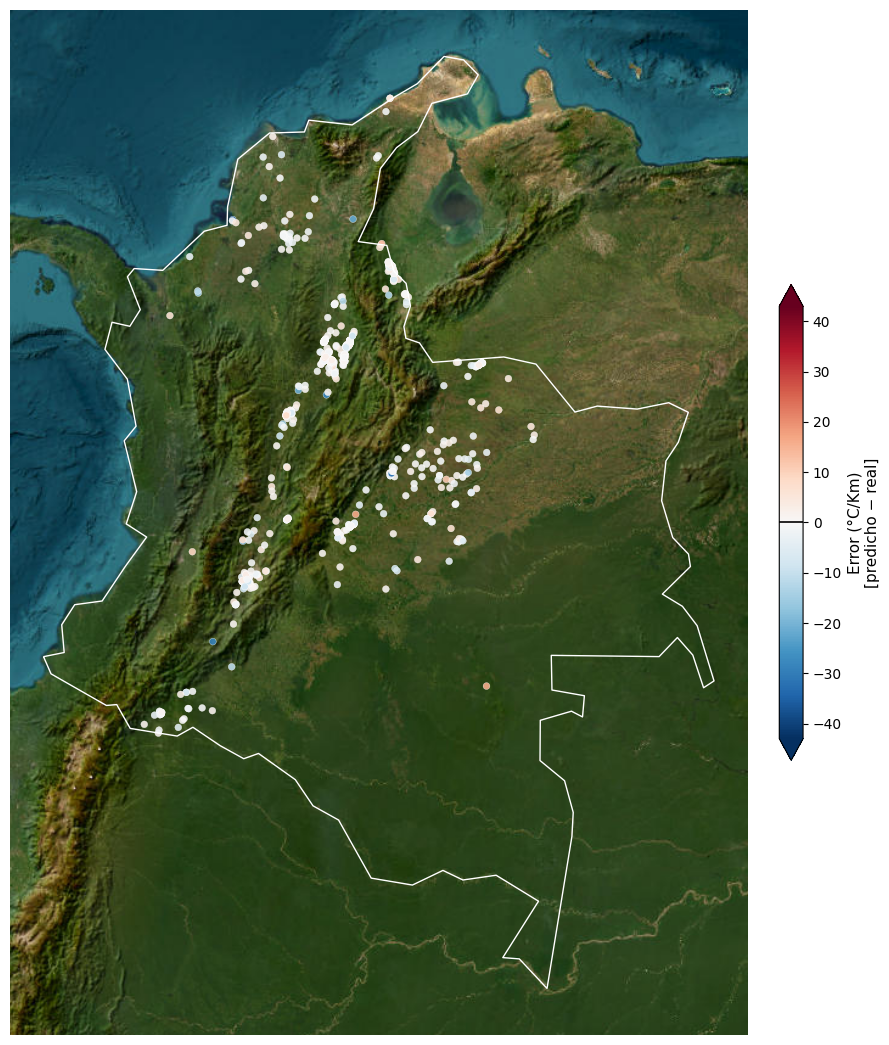

Guardado: mapa_error_catboost_ctx.png / .pdf


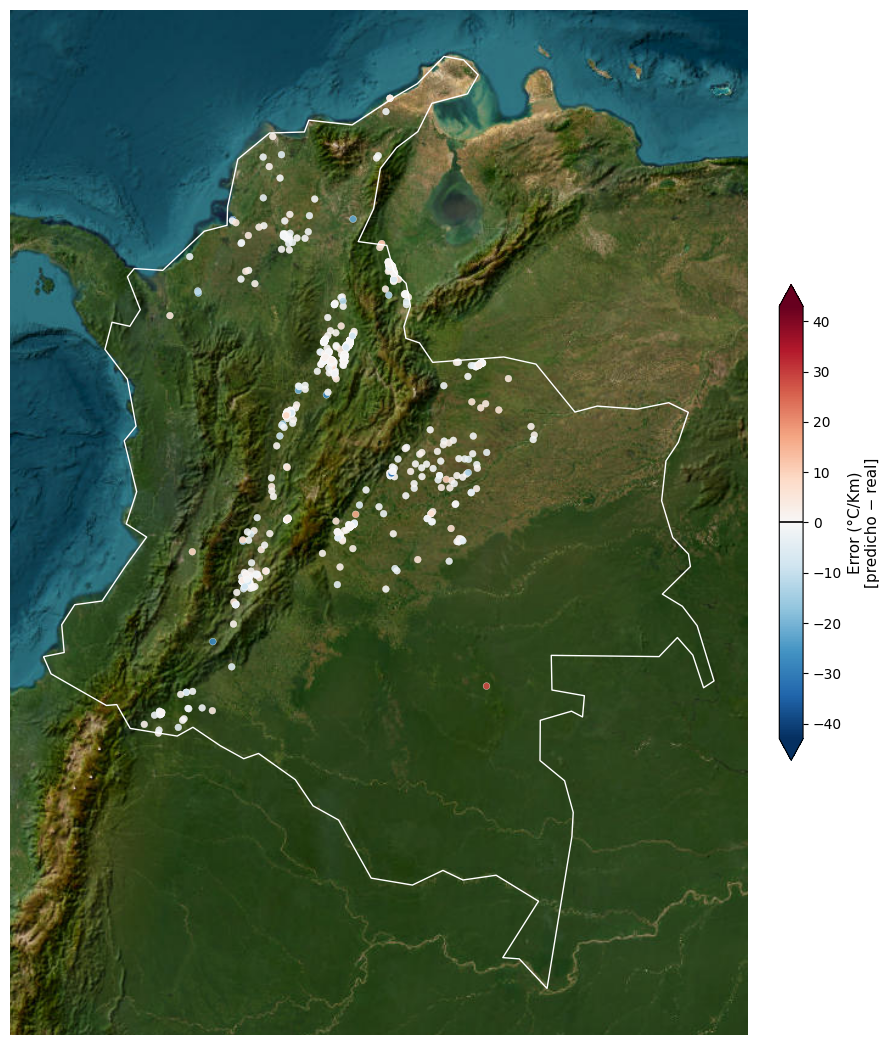

Guardado: mapa_error_xgboost_ctx.png / .pdf


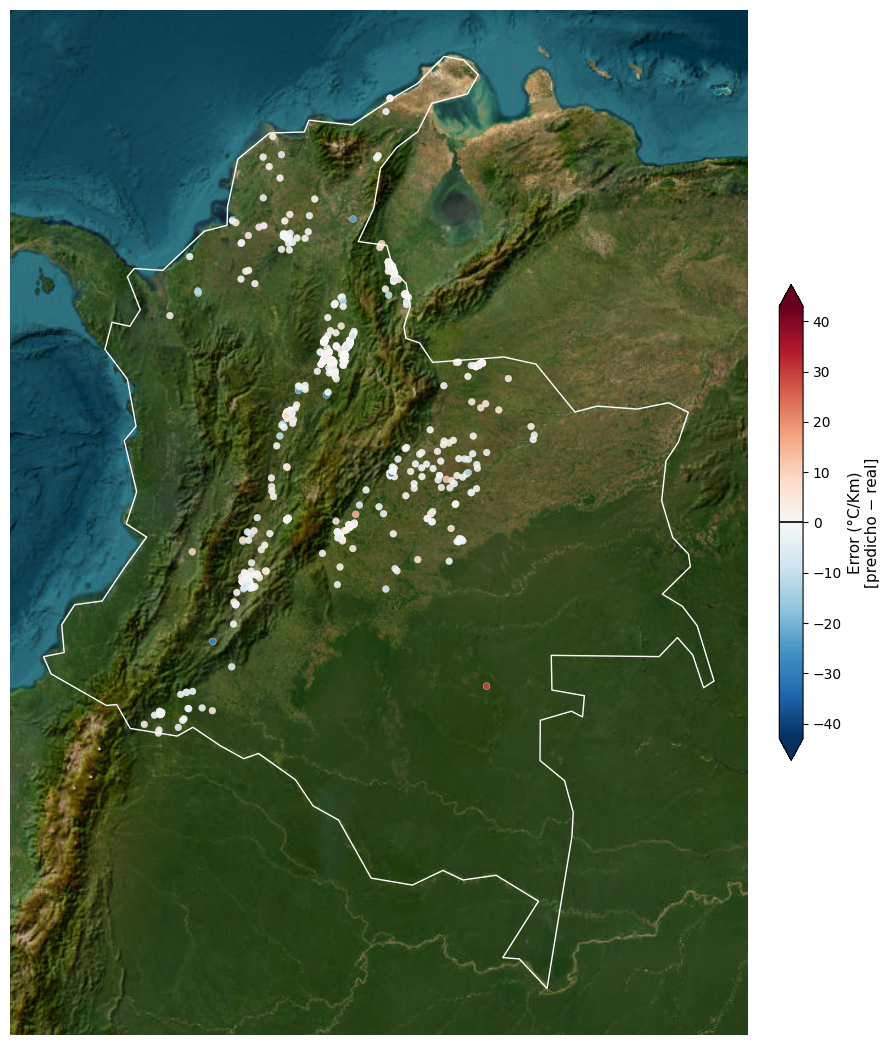

Guardado: mapa_error_lightgbm_ctx.png / .pdf


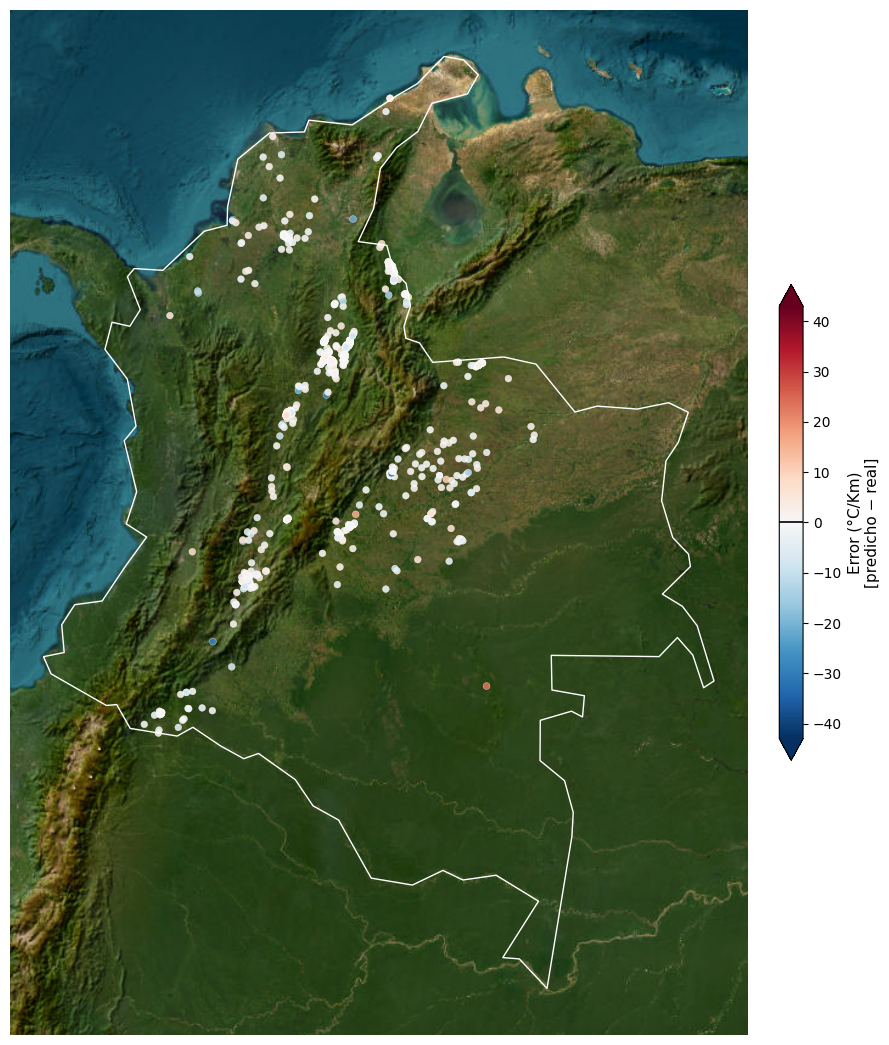

Guardado: mapa_error_cumlrf_ctx.png / .pdf


In [9]:
try:
    import contextily as ctx
    HAS_CTX = True
except ImportError:
    HAS_CTX = False
    print("contextily no disponible")

def plot_mapa_error_con_ctx(col_error, titulo, filename):
    if not HAS_CTX:
        print("contextily no disponible, usando versión sin basemap.")
        plot_mapa_error_sin_ctx(col_error, titulo, filename)
        return

    gdf = gpd.GeoDataFrame(
        df_map[[col_error]].copy(),
        geometry=[Point(xy) for xy in zip(df_map['Longitude'], df_map['Latitude'])],
        crs='EPSG:4326'
    )
    gdf_web      = gdf.to_crs(epsg=3857)
    colombia_web = colombia.to_crs(epsg=3857)

    fig, ax = plt.subplots(figsize=(9, 11))
    colombia_web.boundary.plot(ax=ax, color='white', linewidth=1.0)
    gdf_web.plot(
        column=col_error, cmap=cmap_err, norm=norm_err,
        markersize=24, alpha=0.90, edgecolor='white',
        linewidth=0.25, legend=False, ax=ax,
    )
    try:
        ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery, attribution=False)
    except Exception:
        ctx.add_basemap(ax, source=ctx.providers.OpenTopoMap, attribution=False)

    sm   = cm.ScalarMappable(cmap=cmap_err, norm=norm_err)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.04, extend='both')
    cbar.set_label('Error (°C/Km)\n[predicho − real]', fontsize=11)
    cbar.ax.axhline(y=0, color='black', linewidth=1.2)

    ax.set_axis_off()
    plt.tight_layout()
    fig.savefig(OUT_DIR / f'{filename}.png', dpi=300, bbox_inches='tight')
    fig.savefig(OUT_DIR / f'{filename}.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Guardado: {filename}.png / .pdf")

plot_mapa_error_con_ctx('err_catb',    'Error de Predicción — CatBoost (°C/Km)',          'mapa_error_catboost_ctx')
plot_mapa_error_con_ctx('err_xgb',     'Error de Predicción — XGBoost (°C/Km)',           'mapa_error_xgboost_ctx')
plot_mapa_error_con_ctx('err_lgb',     'Error de Predicción — LightGBM (°C/Km)',          'mapa_error_lightgbm_ctx')
plot_mapa_error_con_ctx('err_cuml_rf', 'Error de Predicción — cuML RandomForest (°C/Km)', 'mapa_error_cumlrf_ctx')
